In [1]:
!pip install anndata==0.8.0

In [2]:
def binary_exp(ct, gdict, marker_dict,org_g_dict, gene_ord):
    heatmap = pd.DataFrame(data = np.zeros((len(ct),len(gene_ord))),index = ct, columns = gene_ord)
    for item in ct:
        if item in marker_dict:
            for g in heatmap.columns:
                org_g = org_g_dict[g]
                if org_g in marker_dict[item]:
                    heatmap.loc[item,g] +=1
                if type(org_g) == float:
                    heatmap.loc[item,g] = np.nan
        else:
            heatmap.loc[item,:] = [np.nan for i in range(len(gene_ord))]
    return(heatmap)

In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
import itertools
import os
import anndata as ad
import math
import csv

/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
with open('../../parent_dict_v2.pkl', 'rb') as f:
    parent_dict = pickle.load(f)

In [4]:
otohomo = pd.read_csv('../../OTO_star_nothreshold_missing_le2_expressionthresh_09082026.tsv', delimiter = '\t',index_col = 'MM')

In [5]:
with open('../../Important_genes/MO_cleaned_sssubclass_03102026_or_hypobkgd_sigupdate_09082026/MO_cleaned_sssubclass_03102026_or_hypobkgd_sigupdate_09082026.pkl', 'rb') as f:
    marker_dict_mo = pickle.load(f)
    
with open('../../Important_genes/CJ_cleaned_sssubclass_v5_or_hypobkgd_sigupdate_09082026/CJ_cleaned_sssubclass_v5_or_hypobkgd_sigupdate_09082026.pkl', 'rb') as f:
    marker_dict_cj = pickle.load(f)
    
with open('../../Important_genes/AC_cleaned_sssubclass_v5_or_hypobkgd_sigupdate_09082026/AC_cleaned_sssubclass_v5_or_hypobkgd_sigupdate_09082026.pkl', 'rb') as f:
    marker_dict_ac = pickle.load(f)
    
with open('../../Important_genes/XT_cleaned_sssubclass_v5_or_hypobkgd_sigupdate_09082026/XT_cleaned_sssubclass_v5_or_hypobkgd_sigupdate_09082026.pkl', 'rb') as f:
    marker_dict_xt = pickle.load(f)
    
with open('../../Important_genes/DR_cleaned_sssubclass_v5_or_hypobkgd_sigupdate_09082026/DR_cleaned_sssubclass_v5_or_hypobkgd_sigupdate_09082026.pkl', 'rb') as f:
    marker_dict_dr = pickle.load(f)
    
with open('../../Important_genes/MM_cleaned_sssubclass_v3_or_hypobkgd_sigupdate_07042026/MM_cleaned_sssubclass_v3_or_hypobkgd_sigupdate_07042026.pkl', 'rb') as f:
    marker_dict_mg = pickle.load(f)

In [6]:
neuropep = pd.read_csv('../../Neuropeptides_receptors_09132026.csv')

In [7]:
neuropep

,Neuropeptide names,Receptors,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,Adcyap1,Adcyap1r1,Vipr1,Vipr2,NaN,NaN,NaN
1,Adm,Calcrl,NaN,NaN,NaN,NaN,NaN
2,Adm2,Calcrl,NaN,NaN,NaN,NaN,NaN
3,Agrp,Mc3r,Mc4r,NaN,NaN,NaN,NaN
4,Agt,Agtr1a,Agtr2,Agtr1b,NaN,NaN,NaN
...,...,...,...,...,...,...,...
90,Enho,Gpr19,NaN,NaN,NaN,NaN,NaN
91,Cgrp,NaN,NaN,NaN,NaN,NaN,NaN
92,Dbi,NaN,NaN,NaN,NaN,NaN,NaN
93,Pcsk1n,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
R_set = set(neuropep.columns) - set(['Neuropeptide names'])

In [9]:
receptors = set(np.unique([str(x).strip() for x in neuropep[R_set].values.ravel() if pd.notna(x)]))

In [10]:
receptors

{'Adcyap1r1',
 'Adipor1',
 'Adipor2',
 'Agtr1a',
 'Agtr1b',
 'Agtr2',
 'Aplnr',
 'Avpr1a',
 'Avpr1b',
 'Avpr2',
 'Bdkrb1',
 'Bdkrb2',
 'Brs3',
 'C3ar1',
 'Calcr',
 'Calcrl',
 'Cckar',
 'Cckbr',
 'Crhr1',
 'Crhr2',
 'Ednra',
 'Ednrb',
 'Galr1',
 'Galr2',
 'Galr3',
 'Gcgr',
 'Ghrhr',
 'Ghsr',
 'Gipr',
 'Glp1r',
 'Gnrhr',
 'Gpr19',
 'Gpr68',
 'Grpr',
 'Hcrtr1',
 'Hcrtr2',
 'Igf1r',
 'Igf2r',
 'Insr',
 'Kiss1r',
 'Lepr',
 'Mc1r',
 'Mc3r',
 'Mc4r',
 'Mc5r',
 'Mchr1',
 'Mchr2',
 'Mlnr',
 'Nmbr',
 'Nmur1',
 'Nmur2',
 'Npbwr1',
 'Npbwr2',
 'Npffr1',
 'Npffr2',
 'Npr1',
 'Npr2',
 'Npr3',
 'Npsr1',
 'Npy1r',
 'Npy2r',
 'Npy4r',
 'Npy5r',
 'Ntsr1',
 'Ntsr2',
 'Oprd1',
 'Oprk1',
 'Oprl1',
 'Oprm1',
 'Oxtr',
 'Prlhr',
 'Prlr',
 'Prokr1',
 'Prokr2',
 'Pth1r',
 'Pth2r',
 'Qrfpr',
 'Rxfp1',
 'Rxfp2',
 'Rxfp3',
 'Sctr',
 'Sstr1',
 'Sstr2',
 'Sstr3',
 'Sstr4',
 'Sstr5',
 'Tacr1',
 'Tacr2',
 'Tacr3',
 'Trhr',
 'Uts2r',
 'Vipr1',
 'Vipr2'}

In [11]:
receptors = list(receptors)
neuropeptides = list(set(neuropep['Neuropeptide names']))

In [12]:
all_np = neuropeptides + receptors

In [13]:
len(receptors)

93

In [14]:
overall_NP_set = set(otohomo.index) & set(all_np)

In [15]:
mg_exp ={i:i for i in overall_NP_set}
mo_exp = {i:otohomo.loc[i,'MO'] for i in overall_NP_set}
cj_exp = {i:otohomo.loc[i,'CJ'] for i in overall_NP_set}
ac_exp = {i:otohomo.loc[i,'AC'] for i in overall_NP_set}
xt_exp = {i:otohomo.loc[i,'XT'] for i in overall_NP_set}
dr_exp = {i:otohomo.loc[i,'DR'] for i in overall_NP_set}

In [16]:
set(mg_exp.keys()) - set(mo_exp.keys())

set()

In [17]:
hypo_names = [i for i in marker_dict_mg.keys() if parent_dict[parent_dict[i]] == 'hypo']
hypo_names.sort()

In [18]:
fixed_gene_ord = list(mg_exp.keys())
bi_mg = binary_exp(hypo_names,mg_exp,marker_dict_mg,mg_exp,fixed_gene_ord)
bi_mo = binary_exp(hypo_names,mg_exp,marker_dict_mo,mo_exp,fixed_gene_ord)
bi_cj = binary_exp(hypo_names,mg_exp,marker_dict_cj,cj_exp,fixed_gene_ord)
bi_ac = binary_exp(hypo_names,mg_exp,marker_dict_ac,ac_exp,fixed_gene_ord)
bi_xt = binary_exp(hypo_names,mg_exp,marker_dict_xt,xt_exp,fixed_gene_ord)
bi_dr = binary_exp(hypo_names,mg_exp,marker_dict_dr,dr_exp,fixed_gene_ord)

In [19]:
bi_xt.shape

(73, 148)

In [20]:
bi_xt.loc[:,'Pomc']

066 NDB-SI-ant Prdm12 Gaba     0.0
073 MEA-BST Sox6 Gaba          0.0
074 MEA-BST Lhx6 Sp9 Gaba      0.0
075 MEA-BST Lhx6 Nr2e1 Gaba    NaN
076 MEA-BST Lhx6 Nfib Gaba     NaN
                              ... 
140 PMd-LHA Foxb1 Glut         0.0
141 PH-SUM Foxa1 Glut          0.0
142 HY Gnrh1 Glut              NaN
143 MM-ant Foxb1 Glut          0.0
144 MM Foxb1 Glut              NaN
Name: Pomc, Length: 73, dtype: float64

In [21]:
cmap = plt.cm.Blues.copy()
cmap.set_bad(color="lightgray")  # color for NaNs

<AxesSubplot:>

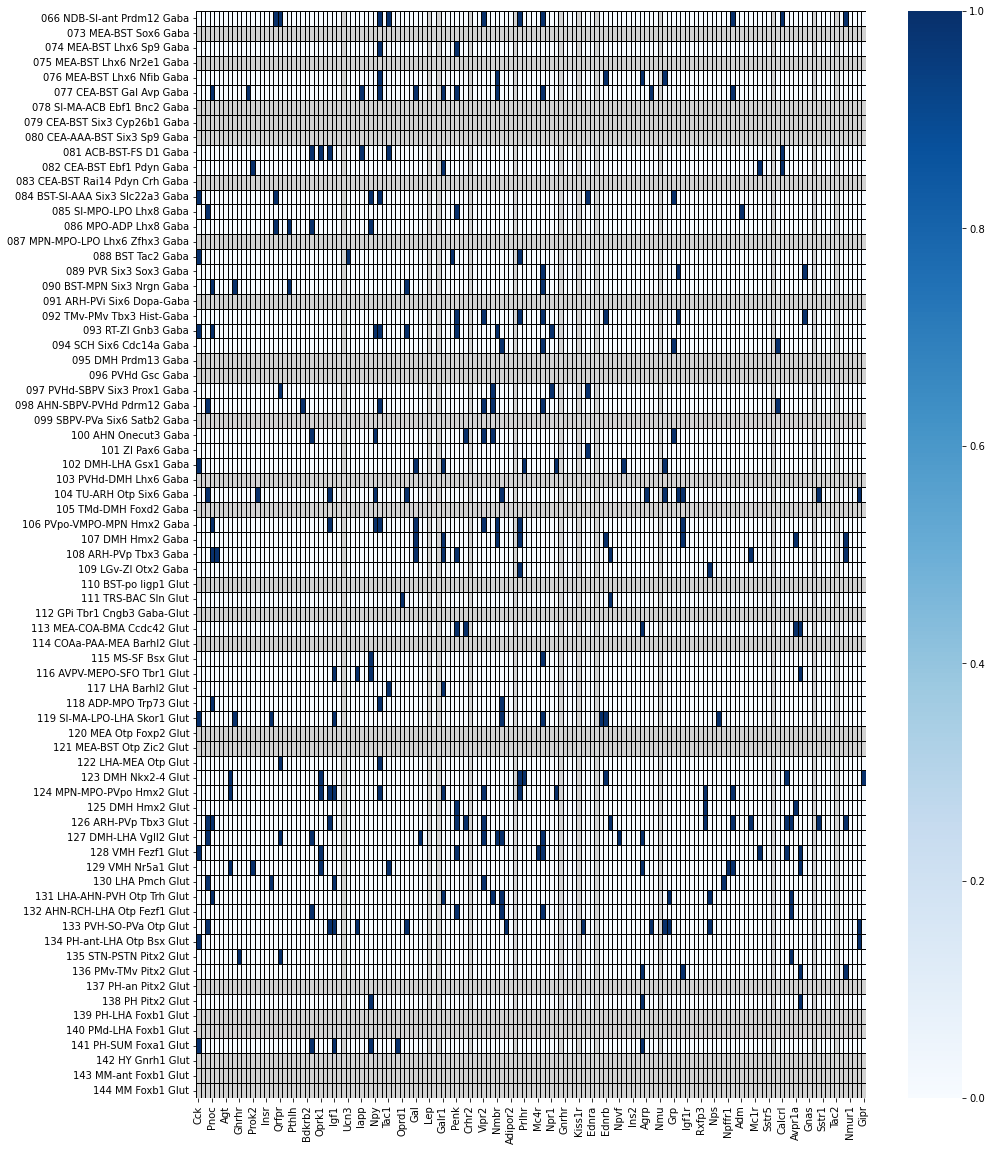

In [22]:
plt.figure(figsize=(15,20))
sns.heatmap(bi_cj, cmap = cmap,  linewidth=0.5, linecolor='black',)

In [23]:
fbi_mg = bi_mg.fillna(0)
fbi_mo = bi_mo.fillna(0)
fbi_cj = bi_cj.fillna(0)
fbi_ac = bi_ac.fillna(0)
fbi_xt = bi_xt.fillna(0)
fbi_dr = bi_dr.fillna(0)

In [24]:
fbi_all = fbi_mg + fbi_mo + fbi_cj + fbi_ac + fbi_xt + fbi_dr

In [25]:
'Crh' in fbi_all.columns

True

In [26]:
fbi_all

,Cck,Npb,Vipr1,Pnoc,Prl,Tacr2,Agt,Pdyn,Oprl1,Ghrhr,...,Sstr1,Apln,Nucb2,Tac2,Adipoq,Grpr,Nmur1,Mchr1,Cckar,Gipr
066 NDB-SI-ant Prdm12 Gaba,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
073 MEA-BST Sox6 Gaba,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0
074 MEA-BST Lhx6 Sp9 Gaba,1.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
075 MEA-BST Lhx6 Nr2e1 Gaba,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
076 MEA-BST Lhx6 Nfib Gaba,2.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140 PMd-LHA Foxb1 Glut,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
141 PH-SUM Foxa1 Glut,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
142 HY Gnrh1 Glut,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
143 MM-ant Foxb1 Glut,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
num_orgs = pd.DataFrame(data = np.zeros((len(fbi_all.index),1)),columns = ['Num orgs'], index = fbi_all.index)
for item in num_orgs.index:
    if item in marker_dict_mg.keys():
        num_orgs.loc[item,'Num orgs'] +=1
    if item in marker_dict_mo.keys():
        num_orgs.loc[item,'Num orgs'] +=1
    if item in marker_dict_cj.keys():
        num_orgs.loc[item,'Num orgs'] +=1
    if item in marker_dict_ac.keys():
        num_orgs.loc[item,'Num orgs'] +=1
    if item in marker_dict_xt.keys():
        num_orgs.loc[item,'Num orgs'] +=1
    if item in marker_dict_dr.keys():
        num_orgs.loc[item,'Num orgs'] +=1

In [28]:
#allows you to set a threshold for the number of species the gene is DE in 
cts = num_orgs[num_orgs['Num orgs'] >= 4].index

In [29]:
np.sum(fbi_all, axis = 0)

Cck      31.0
Npb       2.0
Vipr1    19.0
Pnoc     49.0
Prl       1.0
         ... 
Grpr     24.0
Nmur1    10.0
Mchr1     2.0
Cckar    30.0
Gipr      4.0
Length: 148, dtype: float64

In [30]:
fbi_all = fbi_all.loc[cts,:]

In [31]:
fbi_all.loc[:,'Oprk1']

066 NDB-SI-ant Prdm12 Gaba        0.0
073 MEA-BST Sox6 Gaba             0.0
074 MEA-BST Lhx6 Sp9 Gaba         0.0
076 MEA-BST Lhx6 Nfib Gaba        0.0
077 CEA-BST Gal Avp Gaba          1.0
079 CEA-BST Six3 Cyp26b1 Gaba     0.0
081 ACB-BST-FS D1 Gaba            1.0
082 CEA-BST Ebf1 Pdyn Gaba        0.0
085 SI-MPO-LPO Lhx8 Gaba          0.0
086 MPO-ADP Lhx8 Gaba             1.0
088 BST Tac2 Gaba                 1.0
089 PVR Six3 Sox3 Gaba            0.0
090 BST-MPN Six3 Nrgn Gaba        0.0
091 ARH-PVi Six6 Dopa-Gaba        0.0
092 TMv-PMv Tbx3 Hist-Gaba        1.0
093 RT-ZI Gnb3 Gaba               2.0
094 SCH Six6 Cdc14a Gaba          0.0
097 PVHd-SBPV Six3 Prox1 Gaba     0.0
098 AHN-SBPV-PVHd Pdrm12 Gaba     0.0
100 AHN Onecut3 Gaba              0.0
101 ZI Pax6 Gaba                  0.0
102 DMH-LHA Gsx1 Gaba             0.0
104 TU-ARH Otp Six6 Gaba          0.0
105 TMd-DMH Foxd2 Gaba            0.0
106 PVpo-VMPO-MPN Hmx2 Gaba       3.0
107 DMH Hmx2 Gaba                 1.0
109 LGv-ZI O

In [32]:
total_index = fbi_all.columns[(fbi_all >= 4).any(axis=0)]

In [33]:
len(total_index)

22

In [34]:
total_index

Index(['Pnoc', 'Pdyn', 'Crh', 'Igf1', 'Agtr1a', 'Npy', 'Sst', 'Gal', 'Qrfp',
       'Galr1', 'Oxt', 'Hcrt', 'Nts', 'Npvf', 'Agrp', 'Avp', 'Trh', 'Grp',
       'Calcr', 'Pmch', 'Adcyap1', 'Tac2'],
      dtype='object')

In [35]:
column_map = pd.DataFrame(index = fbi_all.columns, columns = ['npcolor'])
for item in fbi_all.columns:
    if item in neuropeptides:
        column_map.loc[item,'npcolor'] = 'Purple'
    else:
        column_map.loc[item,'npcolor'] = 'Green'

In [36]:
fbi_all.shape

(51, 148)

In [37]:
mg_np = []
mo_np = []
cj_np = []
ac_np= []
xt_np = []
dr_np = []
for item in fbi_all.columns:
    mg_np.append(mg_exp[item])
    mo_np.append(mo_exp[item])
    cj_np.append(cj_exp[item])
    ac_np.append(ac_exp[item])
    xt_np.append(xt_exp[item])
    dr_np.append(dr_exp[item])

In [38]:
with open("../../mg_np_all_09132026.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(mg_np)  
    
with open("../../mo_np_all_09132026.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(mo_np)  
    
with open("../../cj_np_all_09132026.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(cj_np)  
    
with open("../../ac_np_all_09132026.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(ac_np)  
    
with open("../../xt_np_all_09132026.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(xt_np)  
    
with open("../../dr_np_all_09132026.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(dr_np)  

In [39]:
fbi_all.columns

Index(['Cck', 'Npb', 'Vipr1', 'Pnoc', 'Prl', 'Tacr2', 'Agt', 'Pdyn', 'Oprl1',
       'Ghrhr',
       ...
       'Sstr1', 'Apln', 'Nucb2', 'Tac2', 'Adipoq', 'Grpr', 'Nmur1', 'Mchr1',
       'Cckar', 'Gipr'],
      dtype='object', length=148)

In [40]:
np_mapping = pd.DataFrame(data = [list(fbi_all.columns),
                     [mo_exp[i] for i in list(fbi_all.columns)],
                     [cj_exp[i]for i in list(fbi_all.columns)],
                     [ac_exp[i] for i in list(fbi_all.columns)],
                     [xt_exp[i] for i in list(fbi_all.columns)],
                     [dr_exp[i] for i in list(fbi_all.columns)]],
             index = ['Mouse gene name','Vole gene name','Quail gene name','Anole gene name','Xenopus gene name','Zebrafish gene name']).T

In [41]:
np_mapping.to_csv('../../NP_mapping_allorgs_Fig2_09132026.csv')

In [42]:
old_set = ['Hcrt','Npvf','Qrfp','Adcyap1','Pdyn','Igf1','Pmch','Trh','Agtr1a','Oxt','Avp','Crh']

In [43]:
old_set.reverse()

In [44]:
old_set

['Crh',
 'Avp',
 'Oxt',
 'Agtr1a',
 'Trh',
 'Pmch',
 'Igf1',
 'Pdyn',
 'Adcyap1',
 'Qrfp',
 'Npvf',
 'Hcrt']

In [45]:
reindex = ['Grp','Tac2','Nts','Pnoc','Gal','Galr1','Agrp','Npy','Calcr','Sst'] + old_set

In [46]:
set(reindex) - set(fbi_all.columns)

set()

In [47]:
set(total_index) - set(reindex)

set()

In [48]:
set(reindex) - set(total_index)

set()

In [49]:
fbi_all = fbi_all.loc[:,reindex]

In [50]:
len(fbi_all.index)

51

<AxesSubplot:>

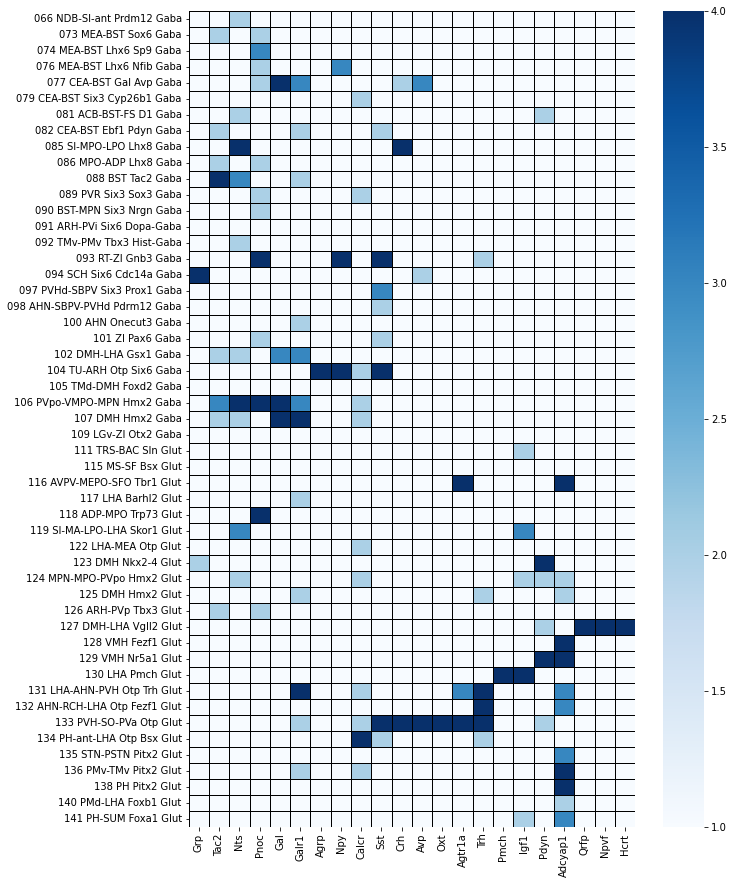

In [51]:
plt.figure(figsize=(10,15))
sns.heatmap(fbi_all, cmap = cmap,  linewidth=0.5, linecolor='black',vmax = 4, vmin = 1)

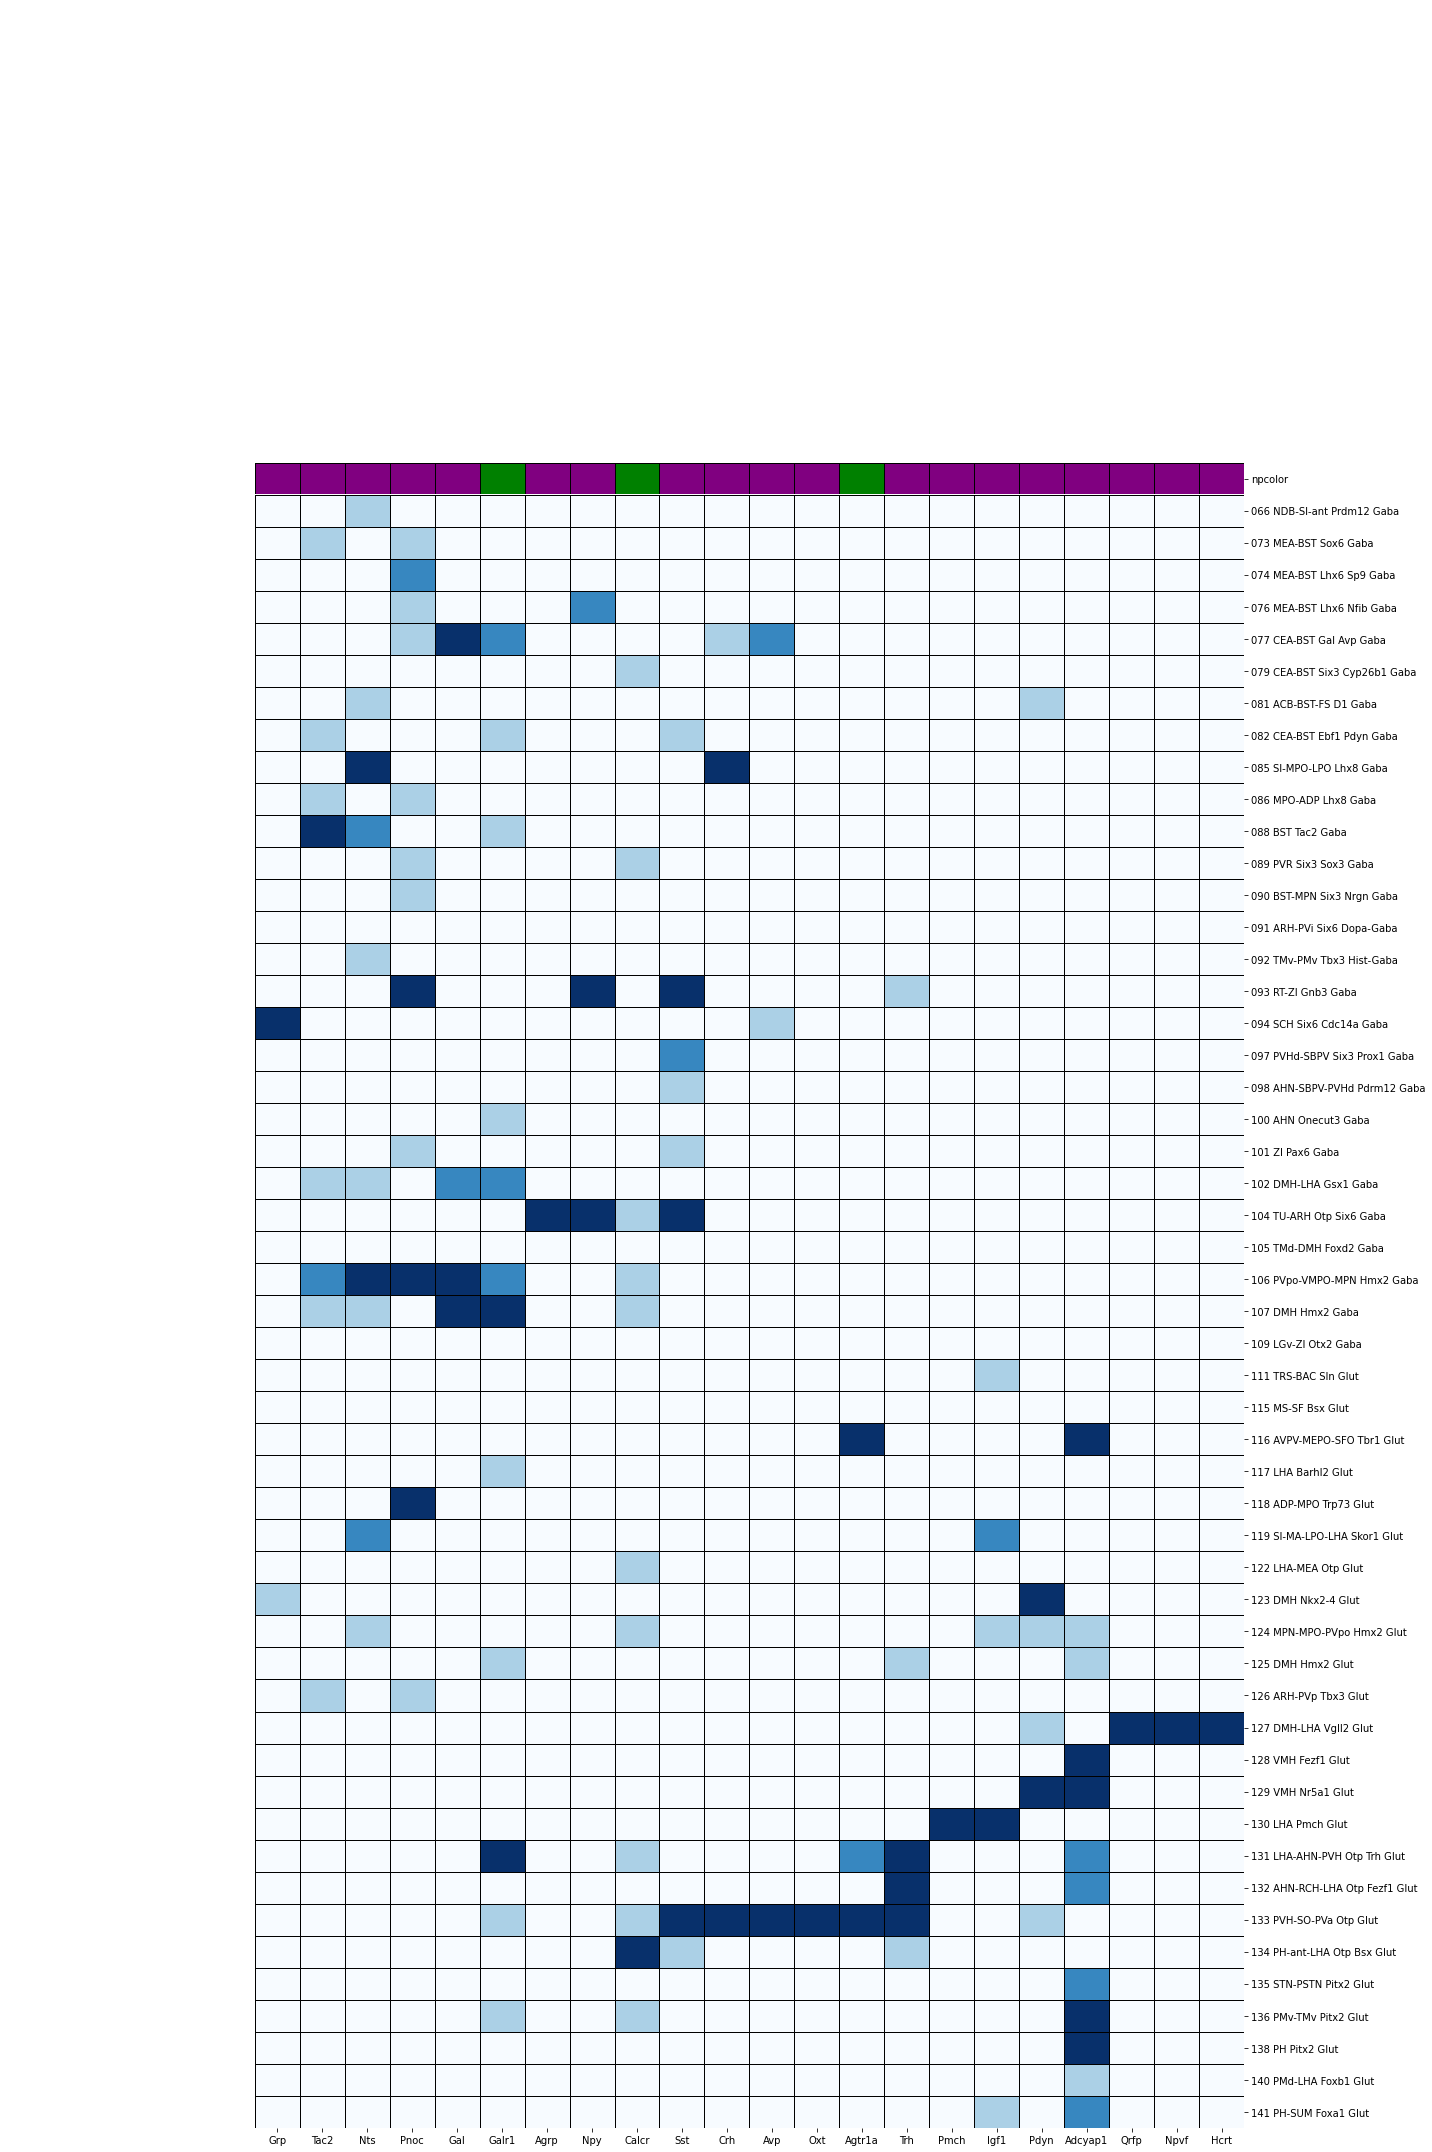

In [52]:
g = sns.clustermap(fbi_all, cmap = cmap,  linewidth=1, linecolor='black',vmax = 4, vmin = 1,col_colors = column_map, row_cluster = False, col_cluster = False, figsize = (20,30), cbar_pos = None)
#g.ax_heatmap.set_xticks([])
#g.ax_heatmap.set_yticks([])
colc_ax = g.ax_col_colors
box = colc_ax.get_position()
colc_ax.set_position([
    box.x0,              # left
    box.y0,       # bottom (shift it up a bit)
    box.width,           # keep width
    box.height * .5    # reduce height (30% of original)
])

plt.savefig('../../Figures/Figures_09202026/Neuropeptide_marker_conservation_missingtwo_09132026.png', dpi = 300,bbox_inches = 'tight')
plt.savefig('../../Figures/Figures_09202026/Neuropeptide_marker_conservation_missingtwo_09132026.svg',bbox_inches = 'tight')
plt.savefig('../../Figures/Figures_09202026/Neuropeptide_marker_conservation_missingtwo_09132026.pdf',bbox_inches = 'tight')